In [1]:
%load_ext autoreload
%autoreload 2

In [11]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.visualization import plot_distribution
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_shor.shor import find_factor, find_order

Simulator

Start search for the order of 7 in Z_15
Found value 4 for the order of 7 in Z_15. If running on noisy quantum hardware, 4 might be a multiple of the order instead.


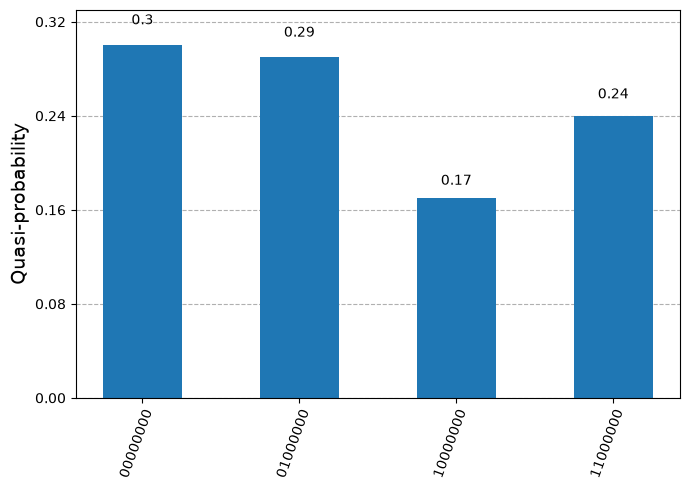

In [15]:
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import SamplerV2 as AerSampler

aer_sim = AerSimulator()
pm = generate_preset_pass_manager(backend=aer_sim, optimization_level=1)
sampler = AerSampler()

r, dist = find_order(A=7, N=15, sampler=sampler, pass_manager=pm, num_shots=100)
plot_distribution(dist)

Start search for the order of 7 in Z_15
Found value 4 for the order of 7 in Z_15. If running on noisy quantum hardware, 4 might be a multiple of the order instead.


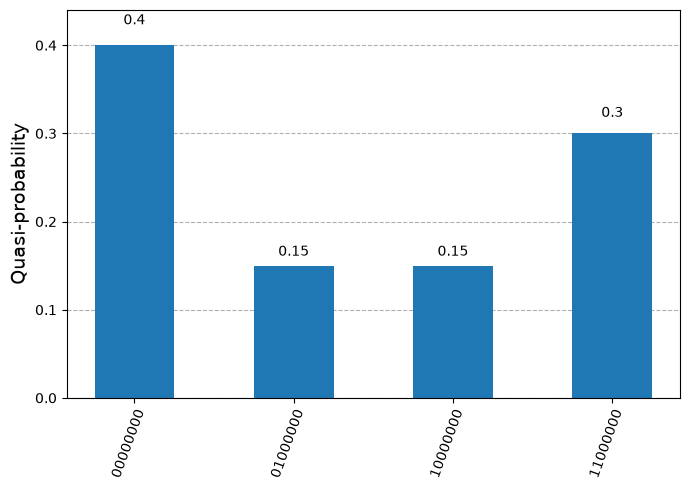

In [16]:
# Using Ripple-Carry adder and one-control circuit

r, dist = find_order(
    A=7, N=15, sampler=sampler, pass_manager=pm, num_shots=20, adder="rc_adder", one_control_circuit=True
)
plot_distribution(dist)

In [17]:
QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token="J3X0m50xa3vyo-p8bQXxak-o9OGLBWFw995QxFetDEuE",
    overwrite=True
)

service = QiskitRuntimeService()

qiskit_runtime_service.__init__:WARNING:2026-08-27 15:19:19,773: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.


In [18]:
# backend = service.backend("ibm_brisbane")
n_qubits = 127
backend = service.least_busy(operational=True, simulator=False, min_num_qubits=n_qubits)
print(f"backend: {backend.name}")
pm = generate_preset_pass_manager(target=backend.target, optimization_level=1)
sampler = Sampler(mode=backend)

qiskit_runtime_service.backends:WARNING:2026-08-27 15:19:57,287: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-08-27 15:20:01,245: Using instance: open-instance, plan: open


backend: ibm_fez


Start search for the order of 7 in Z_15
Found value 4 for the order of 7 in Z_15. If running on noisy quantum hardware, 4 might be a multiple of the order instead.


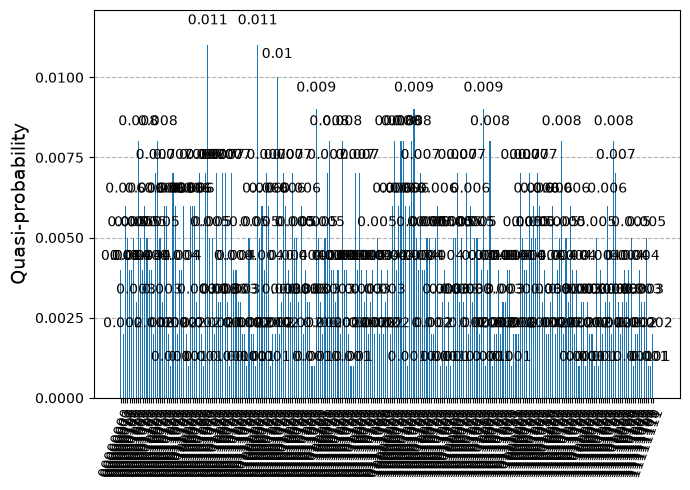

In [19]:
r, dist = find_order(A=7, N=15, sampler=sampler, pass_manager=pm, num_shots=1000)

plot_distribution(dist)

Start search for the order of 7 in Z_15
Failed to find order of 7 in Z_15


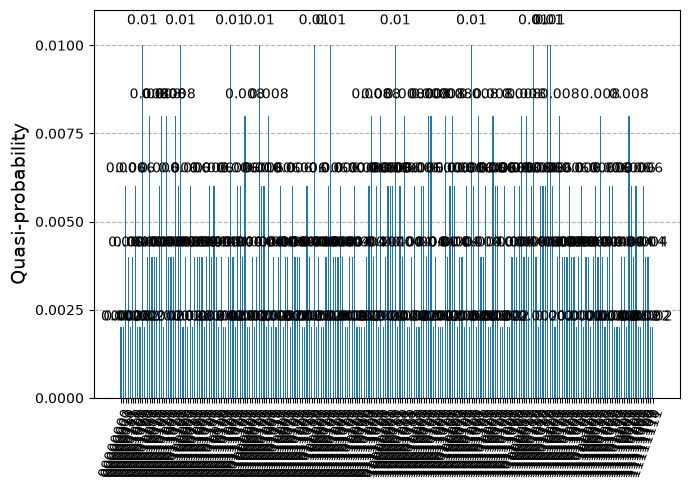

In [20]:
# Using Ripple-Carry adder and one-control circuit
r, dist = find_order(
    A=7, N=15, sampler=sampler, pass_manager=pm, num_shots=500, adder="rc_adder", one_control_circuit=True
)

plot_distribution(dist)

In [21]:
f = find_factor(
    N=15, sampler=sampler, pass_manager=pm, num_tries=3, num_shots_per_trial=1000, one_control_circuit=True
)

Lucky guess of 12, found factor 3
